In [42]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
from docx import Document
from docx.shared import Inches, Pt
from docx.enum.text import WD_ALIGN_PARAGRAPH

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
os.makedirs("figures", exist_ok=True)
df = pd.read_csv(r"C:\Users\acer\Downloads\synthetic_heart_disease_dataset.csv", keep_default_na=False)

print("Shape:", df.shape)
print(df.head())
print("\n--- INFO ---")
df.info()


Shape: (50000, 21)
   Age  Gender  Weight  Height   BMI  Smoking Alcohol_Intake  \
0   48    Male      78     157  26.4    Never           None   
1   35  Female      73     163  33.0    Never            Low   
2   79  Female      88     152  32.3    Never           None   
3   75    Male     106     171  37.4    Never       Moderate   
4   34  Female      65     191  18.5  Current           None   

  Physical_Activity     Diet Stress_Level  ...  Diabetes  Hyperlipidemia  \
0         Sedentary  Healthy       Medium  ...         0               1   
1            Active  Average         High  ...         0               1   
2          Moderate  Average       Medium  ...         0               0   
3          Moderate  Average          Low  ...         0               1   
4         Sedentary  Healthy          Low  ...         1               0   

   Family_History  Previous_Heart_Attack  Systolic_BP  Diastolic_BP  \
0               1                      0          104            99 

In [3]:
# 2. DATA QUALITY
# ===============================================================
n_missing = int(df.isnull().sum().sum())
n_dupes = int(df.duplicated().sum())
print("\nMissing values:", n_missing)
print("Duplicate rows:", n_dupes)
df = df.drop_duplicates().reset_index(drop=True)



Missing values: 0
Duplicate rows: 0


In [44]:
target = "Heart_Disease"
num_cols = ["Age", "Weight", "Height", "BMI", "Systolic_BP", "Diastolic_BP",
            "Heart_Rate", "Blood_Sugar_Fasting", "Cholesterol_Total"]
bin_cols = ["Hypertension", "Diabetes", "Hyperlipidemia",
            "Family_History", "Previous_Heart_Attack"]
cat_cols = ["Gender", "Smoking", "Alcohol_Intake", "Physical_Activity",
            "Diet", "Stress_Level"]



In [5]:

print("\n--- DESCRIPTIVE STATISTICS (numerical) ---")
summary = df[num_cols].describe().T.round(2)
print(summary)

print("\n--- SKEWNESS / KURTOSIS ---")
sk = pd.DataFrame({"skew": df[num_cols].skew(), "kurtosis": df[num_cols].kurt()}).round(3)
print(sk)

print("\n--- CATEGORICAL VALUE COUNTS ---")
for c in cat_cols + bin_cols:
    print(f"\n{c}:\n{df[c].value_counts().to_string()}")

class_pct = (df[target].value_counts(normalize=True) * 100).round(1)
print("\n--- TARGET BALANCE (%) ---")
print(class_pct)

# Outliers (IQR)
outliers = {}
for c in num_cols:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    outliers[c] = int(((df[c] < q1 - 1.5 * iqr) | (df[c] > q3 + 1.5 * iqr)).sum())
print("\n--- OUTLIERS (IQR) ---")
print(outliers)



--- DESCRIPTIVE STATISTICS (numerical) ---
                       count    mean    std    min    25%    50%    75%    max
Age                  50000.0   54.46  14.44   30.0   42.0   54.0   67.0   79.0
Weight               50000.0   84.55  20.21   50.0   67.0   85.0  102.0  119.0
Height               50000.0  174.46  14.42  150.0  162.0  174.0  187.0  199.0
BMI                  50000.0   28.98   6.37   18.0   23.5   29.0   34.5   40.0
Systolic_BP          50000.0  139.30  23.08  100.0  119.0  139.0  159.0  179.0
Diastolic_BP         50000.0   89.53  17.26   60.0   75.0   90.0  104.0  119.0
Heart_Rate           50000.0   84.45  14.49   60.0   72.0   85.0   97.0  109.0
Blood_Sugar_Fasting  50000.0  124.49  31.69   70.0   97.0  125.0  152.0  179.0
Cholesterol_Total    50000.0  224.56  43.16  150.0  187.0  225.0  262.0  299.0

--- SKEWNESS / KURTOSIS ---
                      skew  kurtosis
Age                  0.008    -1.204
Weight              -0.003    -1.198
Height              -0.000

In [7]:
# 5. FEATURE ENGINEERING (for deeper insight)
# ===============================================================
df["Age_Group"] = pd.cut(df["Age"], [0, 30, 45, 60, 75, 100],
                         labels=["<30", "30-44", "45-59", "60-74", "75+"])
df["BMI_Category"] = pd.cut(df["BMI"], [0, 18.5, 25, 30, 100],
                            labels=["Underweight", "Normal", "Overweight", "Obese"])
df["BP_Category"] = pd.cut(df["Systolic_BP"], [0, 120, 130, 140, 300],
                           labels=["Normal", "Elevated", "High-1", "High-2"])
df["Chol_Category"] = pd.cut(df["Cholesterol_Total"], [0, 200, 240, 1000],
                             labels=["Desirable", "Borderline", "High"])
df["Pulse_Pressure"] = df["Systolic_BP"] - df["Diastolic_BP"]

# 


In [11]:
def save(name):
    plt.tight_layout()
    path = f"figures/{name}.png"
    plt.savefig(path, dpi=130)
    plt.show()
    plt.close()
    return path

figs = {}

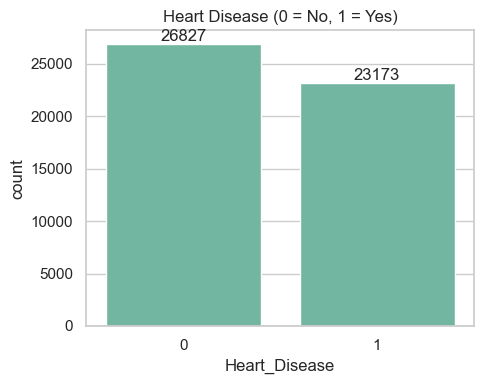

In [12]:
plt.figure(figsize=(5, 4))
ax = sns.countplot(x=target, data=df)
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
plt.title("Heart Disease (0 = No, 1 = Yes)")
figs["target"] = save("01_target")


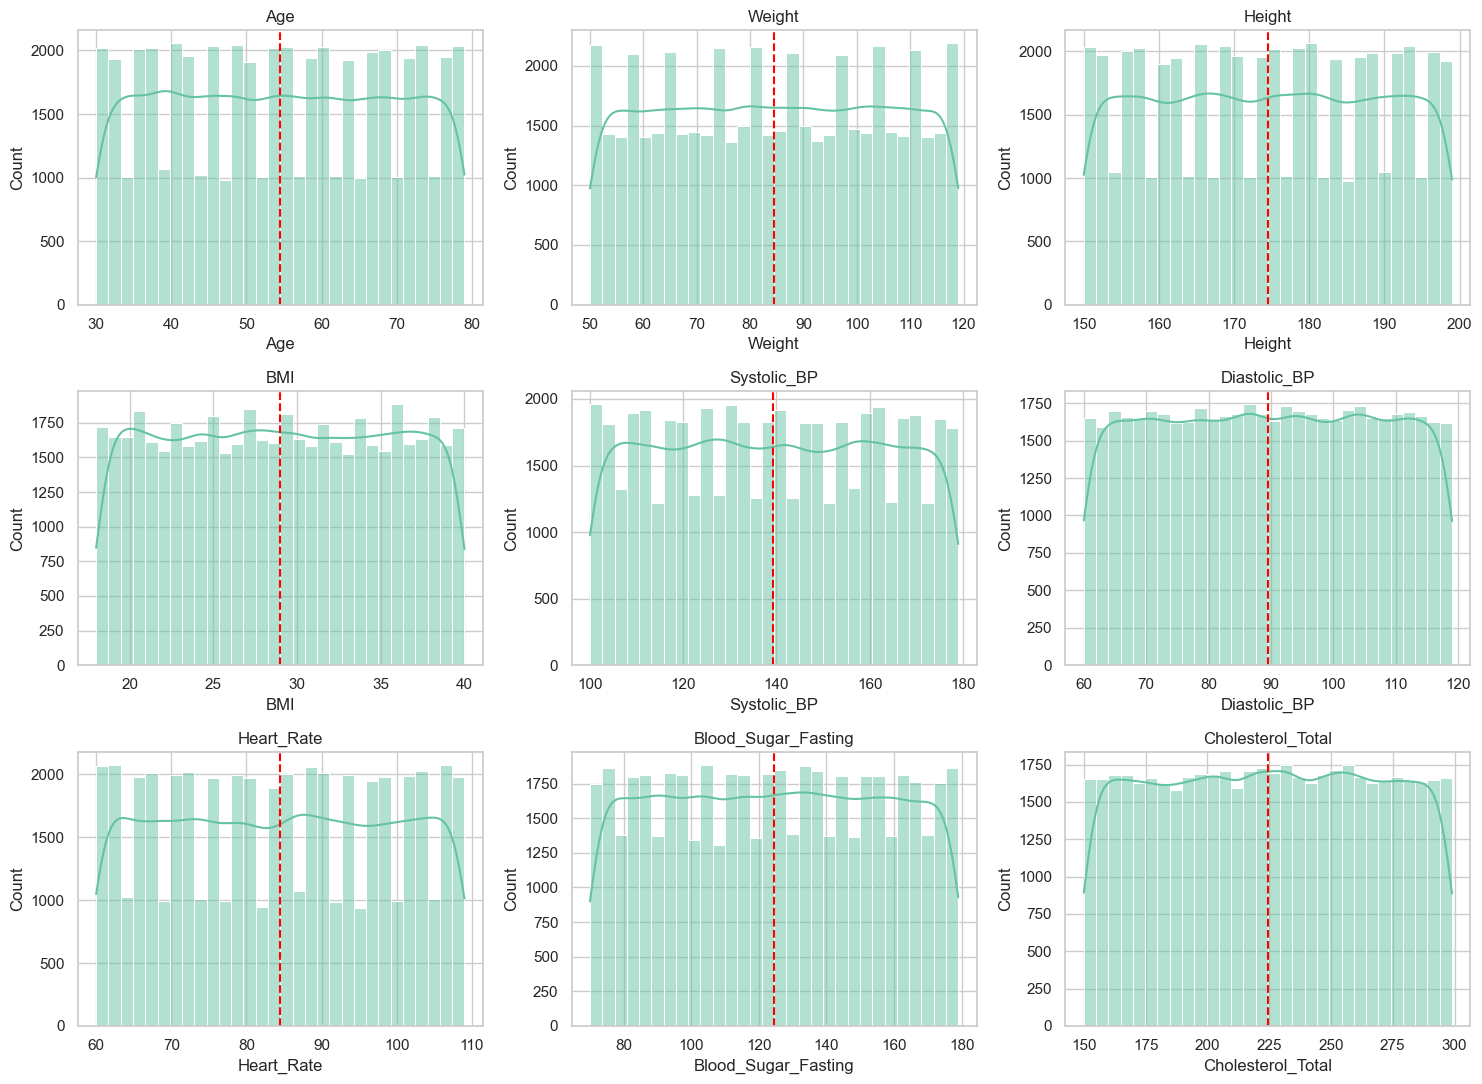

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, c in zip(axes.flatten(), num_cols):
    sns.histplot(df[c], kde=True, ax=ax, bins=30)
    ax.axvline(df[c].mean(), color="red", ls="--")
    ax.set_title(f"{c}")
figs["hist"] = save("02_histograms")


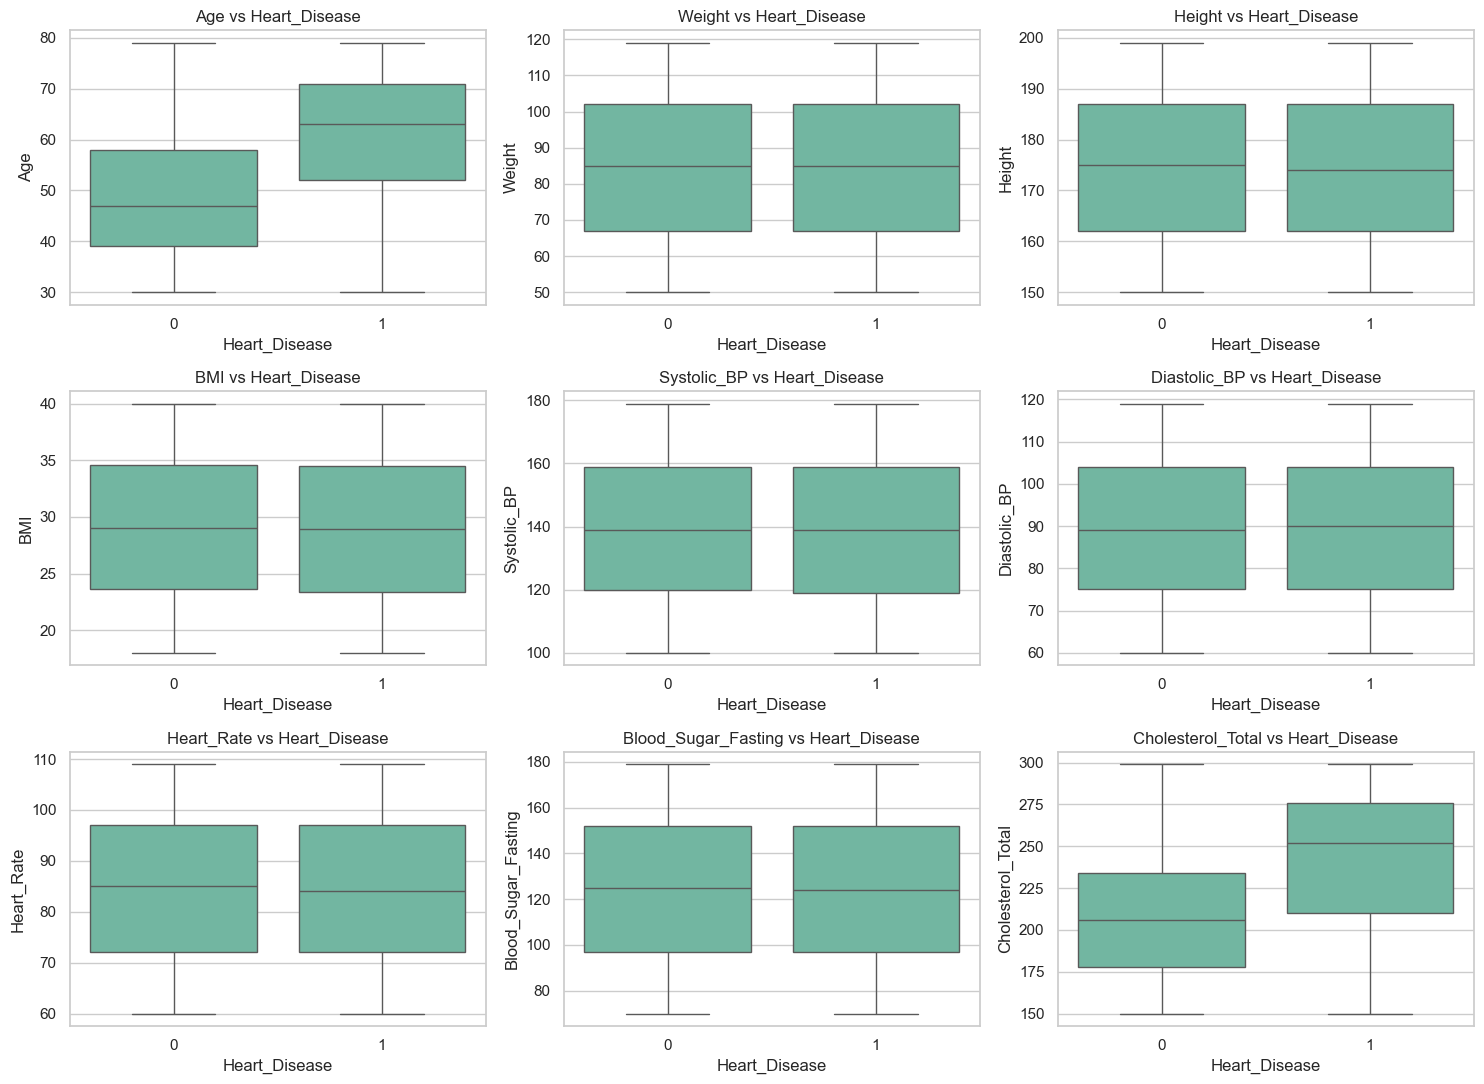

In [15]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, c in zip(axes.flatten(), num_cols):
    sns.boxplot(x=target, y=c, data=df, ax=ax)
    ax.set_title(f"{c} vs {target}")
figs["box"] = save("03_boxplots")


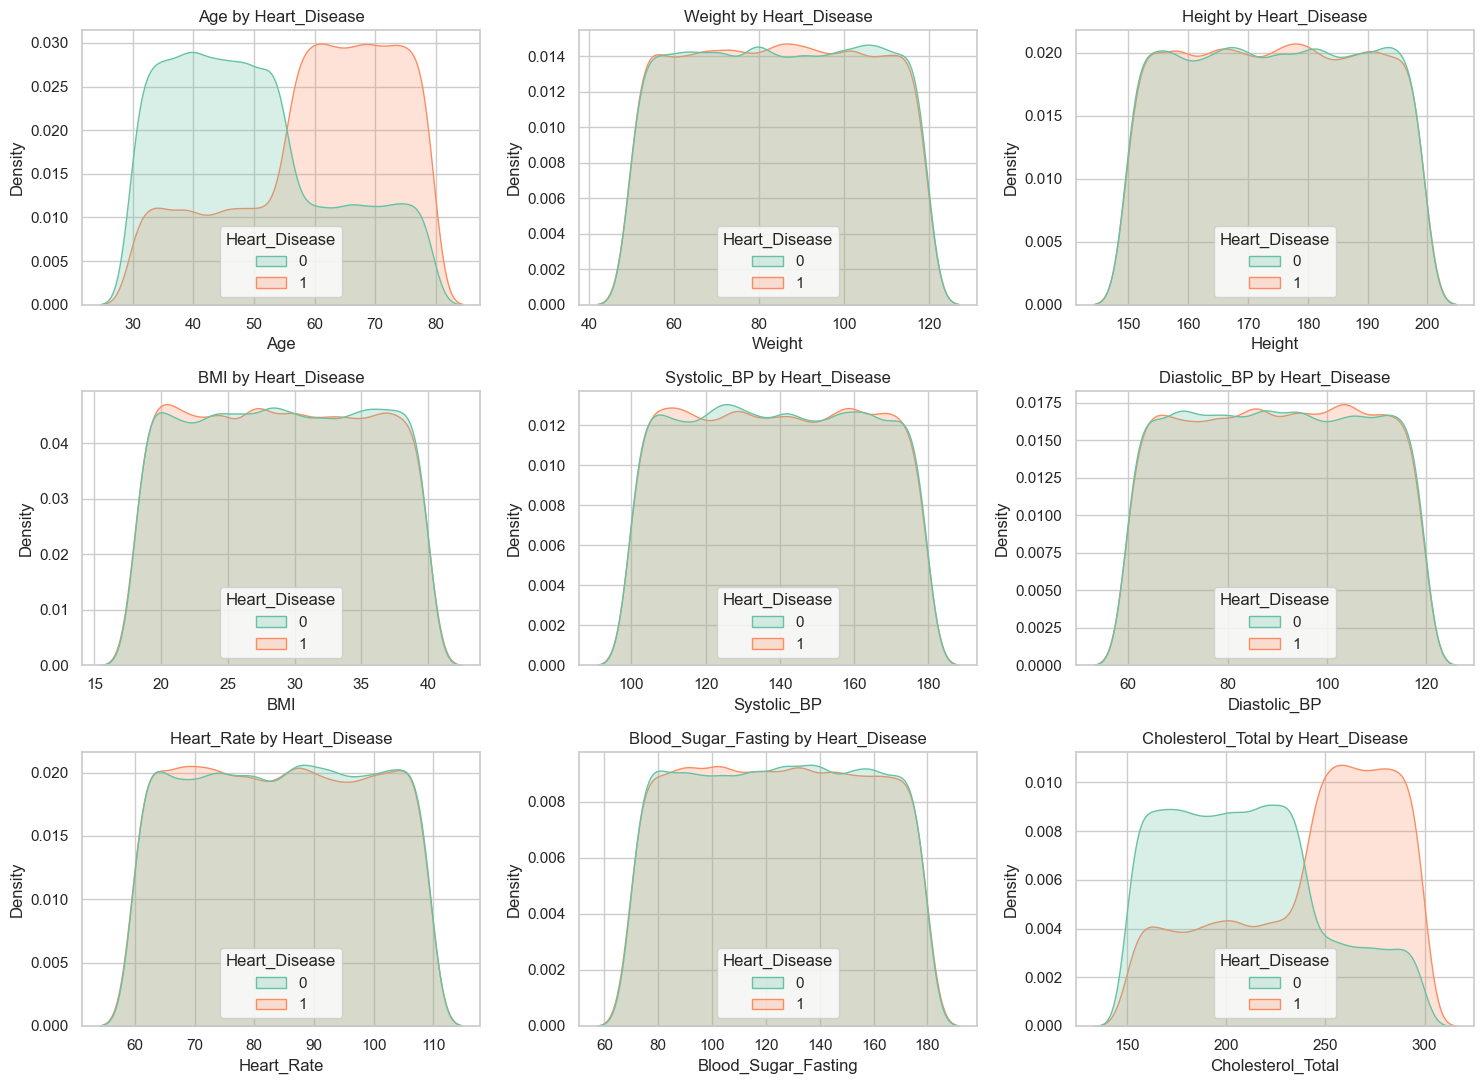

In [16]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, c in zip(axes.flatten(), num_cols):
    sns.kdeplot(data=df, x=c, hue=target, fill=True, common_norm=False, ax=ax)
    ax.set_title(f"{c} by {target}")
figs["kde"] = save("04_kde")


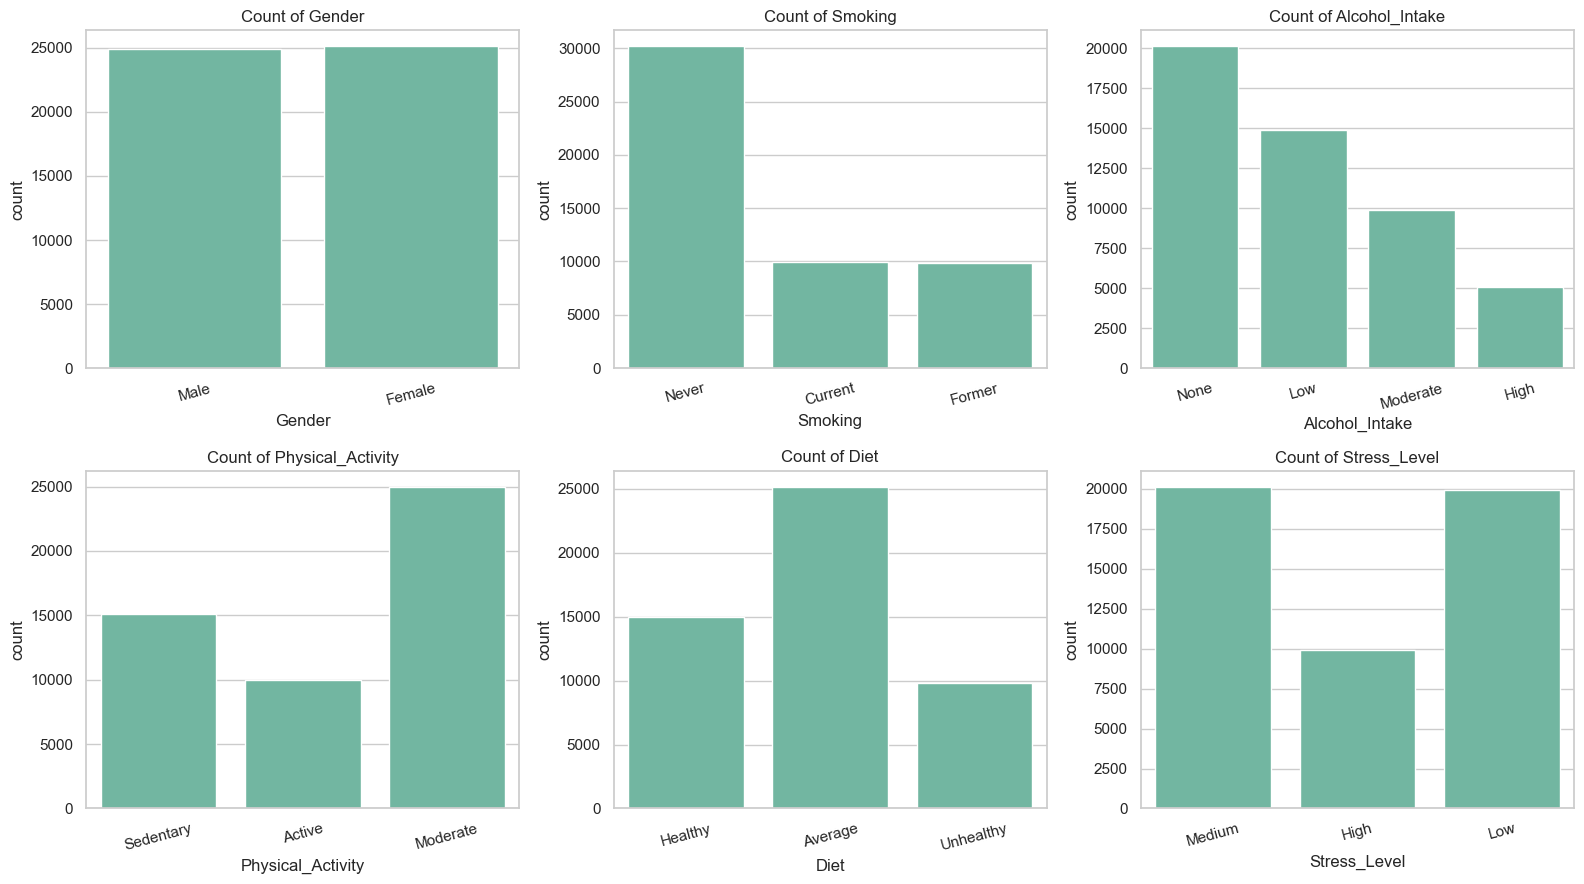

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, c in zip(axes.flatten(), cat_cols):
    sns.countplot(x=c, data=df, ax=ax)
    ax.set_title(f"Count of {c}")
    ax.tick_params(axis="x", rotation=15)
figs["cat_count"] = save("05_cat_counts")

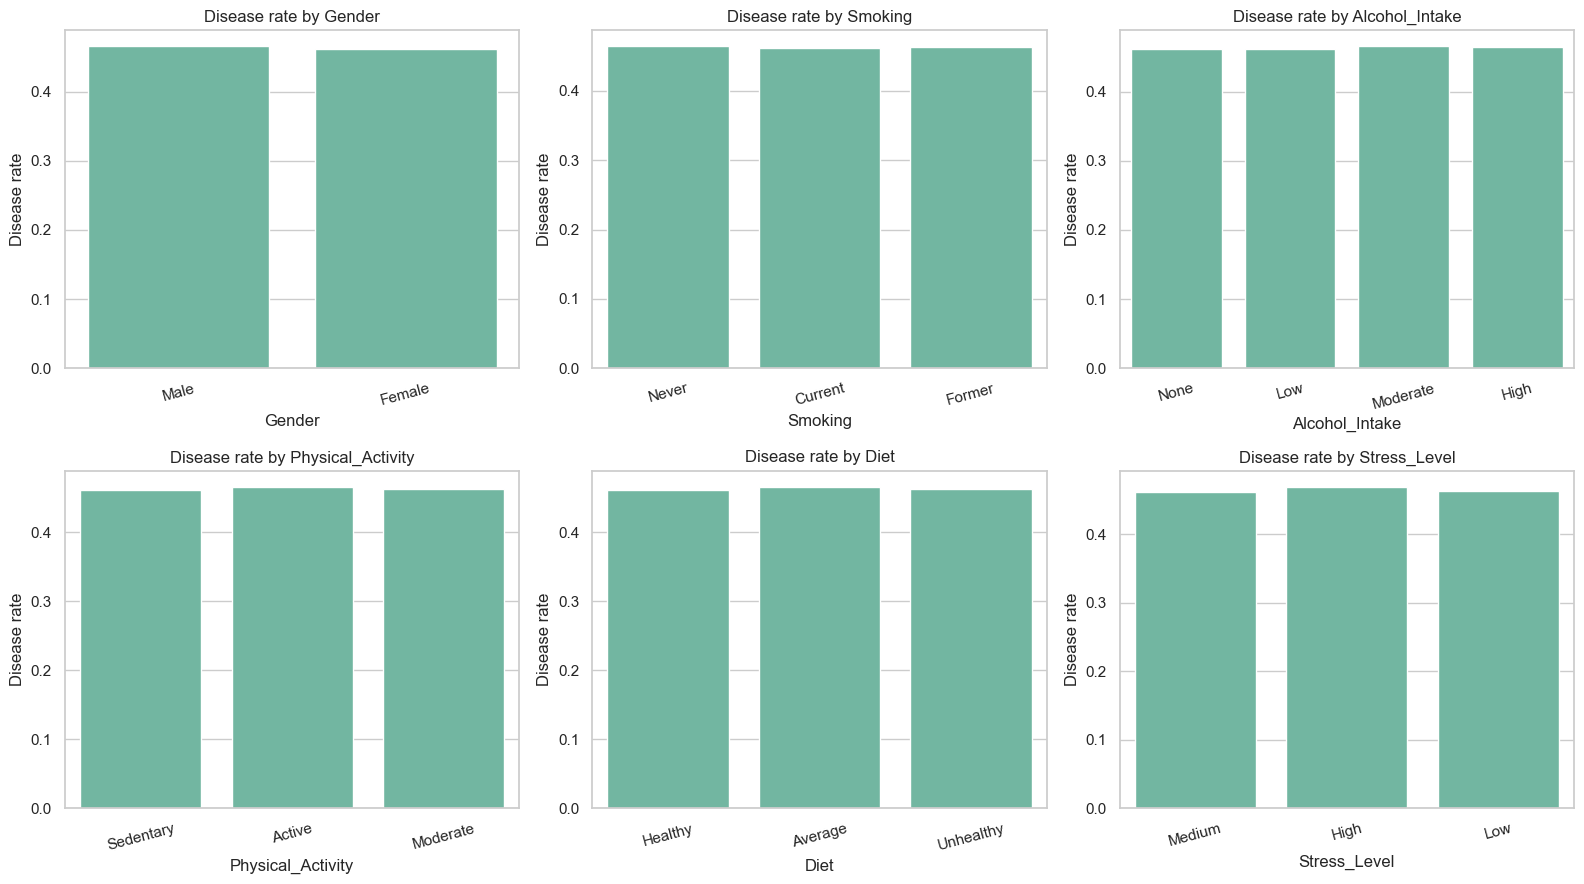

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, c in zip(axes.flatten(), cat_cols):
    sns.barplot(x=c, y=target, data=df, ax=ax, errorbar=None)
    ax.set_ylabel("Disease rate")
    ax.set_title(f"Disease rate by {c}")
    ax.tick_params(axis="x", rotation=15)
figs["cat_rate"] = save("06_cat_vs_target")

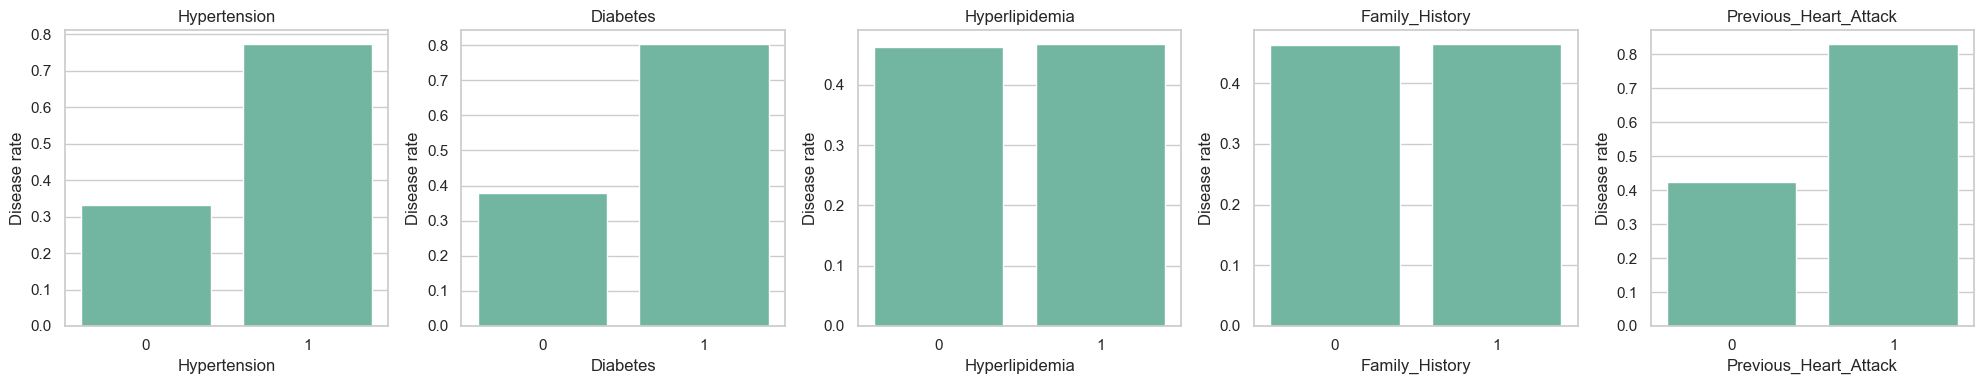

In [19]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, c in zip(axes, bin_cols):
    sns.barplot(x=c, y=target, data=df, ax=ax, errorbar=None)
    ax.set_ylabel("Disease rate")
    ax.set_title(c)
figs["bin_rate"] = save("07_binary_vs_target")


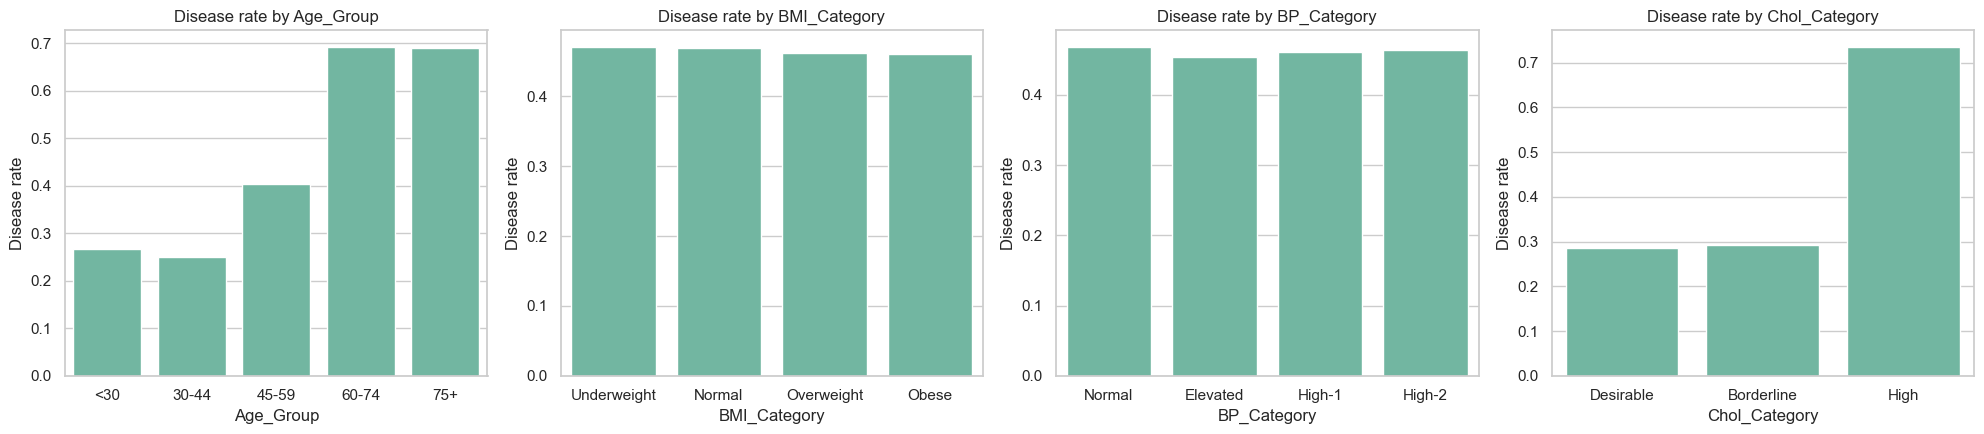

In [20]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, c in zip(axes, ["Age_Group", "BMI_Category", "BP_Category", "Chol_Category"]):
    sns.barplot(x=c, y=target, data=df, ax=ax, errorbar=None)
    ax.set_ylabel("Disease rate")
    ax.set_title(f"Disease rate by {c}")
figs["groups"] = save("08_groups_vs_target")

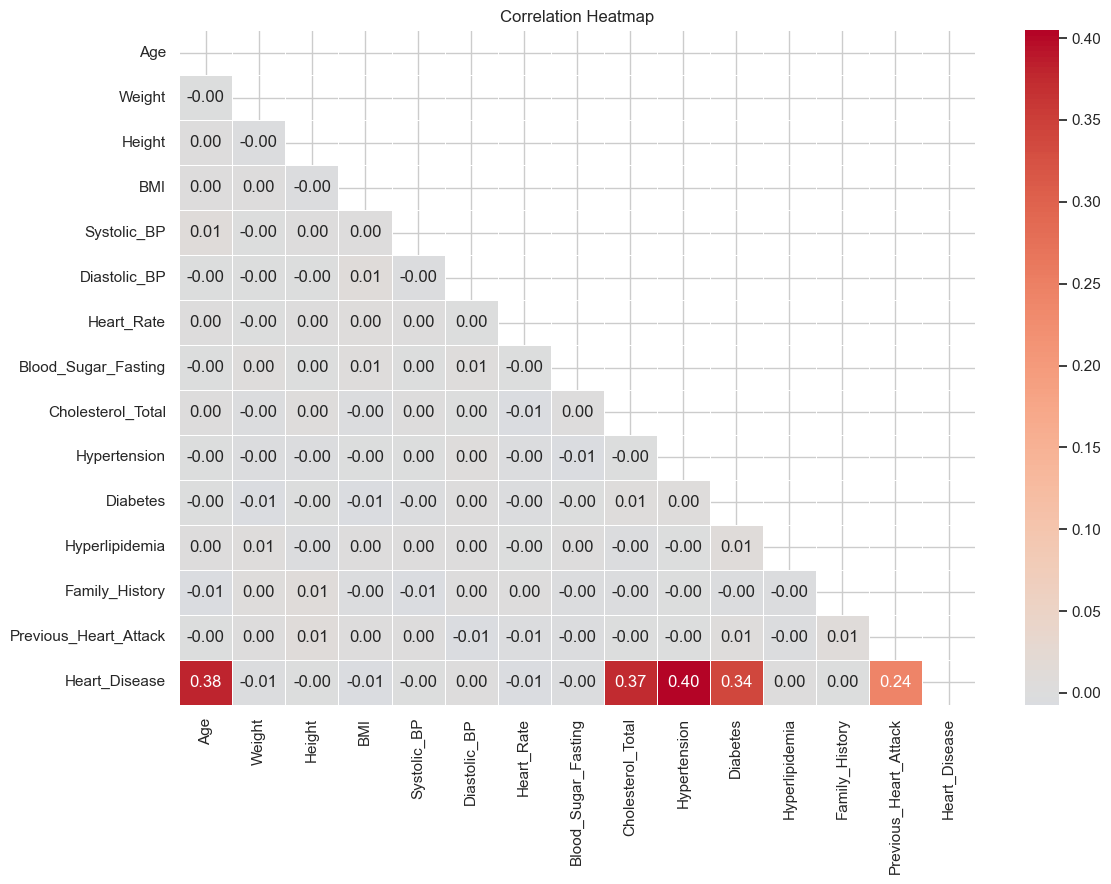

In [21]:
corr_df = df[num_cols + bin_cols + [target]]
corr = corr_df.corr()
plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            mask=np.triu(np.ones_like(corr, dtype=bool)), linewidths=0.4)
plt.title("Correlation Heatmap")
figs["heat"] = save("09_heatmap")



--- CORRELATION WITH TARGET ---
Hypertension             0.405
Age                      0.380
Cholesterol_Total        0.374
Diabetes                 0.338
Previous_Heart_Attack    0.243
Hyperlipidemia           0.004
Diastolic_BP             0.003
Family_History           0.001
Systolic_BP             -0.001
Height                  -0.001
Blood_Sugar_Fasting     -0.003
Weight                  -0.005
BMI                     -0.007
Heart_Rate              -0.007
Name: Heart_Disease, dtype: float64


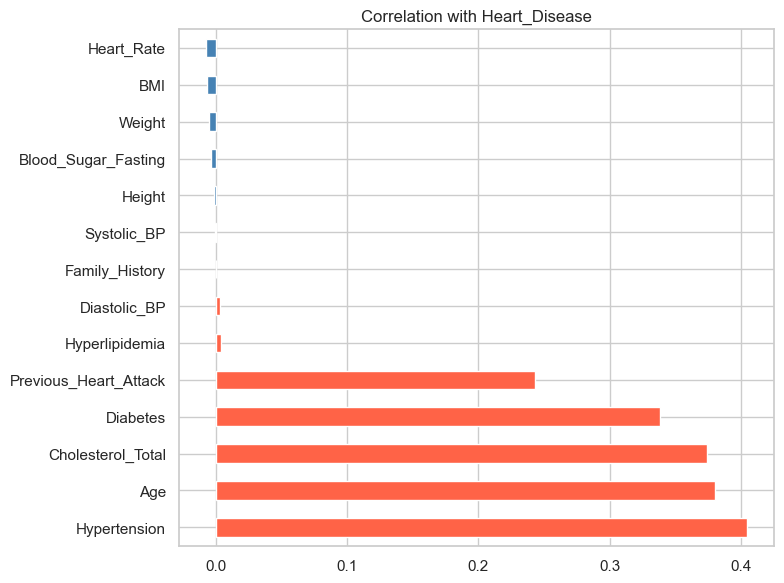

In [22]:
target_corr = corr[target].drop(target).sort_values(ascending=False)
print("\n--- CORRELATION WITH TARGET ---")
print(target_corr.round(3))
plt.figure(figsize=(8, 6))
target_corr.plot(kind="barh", color=np.where(target_corr > 0, "tomato", "steelblue"))
plt.title("Correlation with Heart_Disease")
figs["tcorr"] = save("10_target_corr")

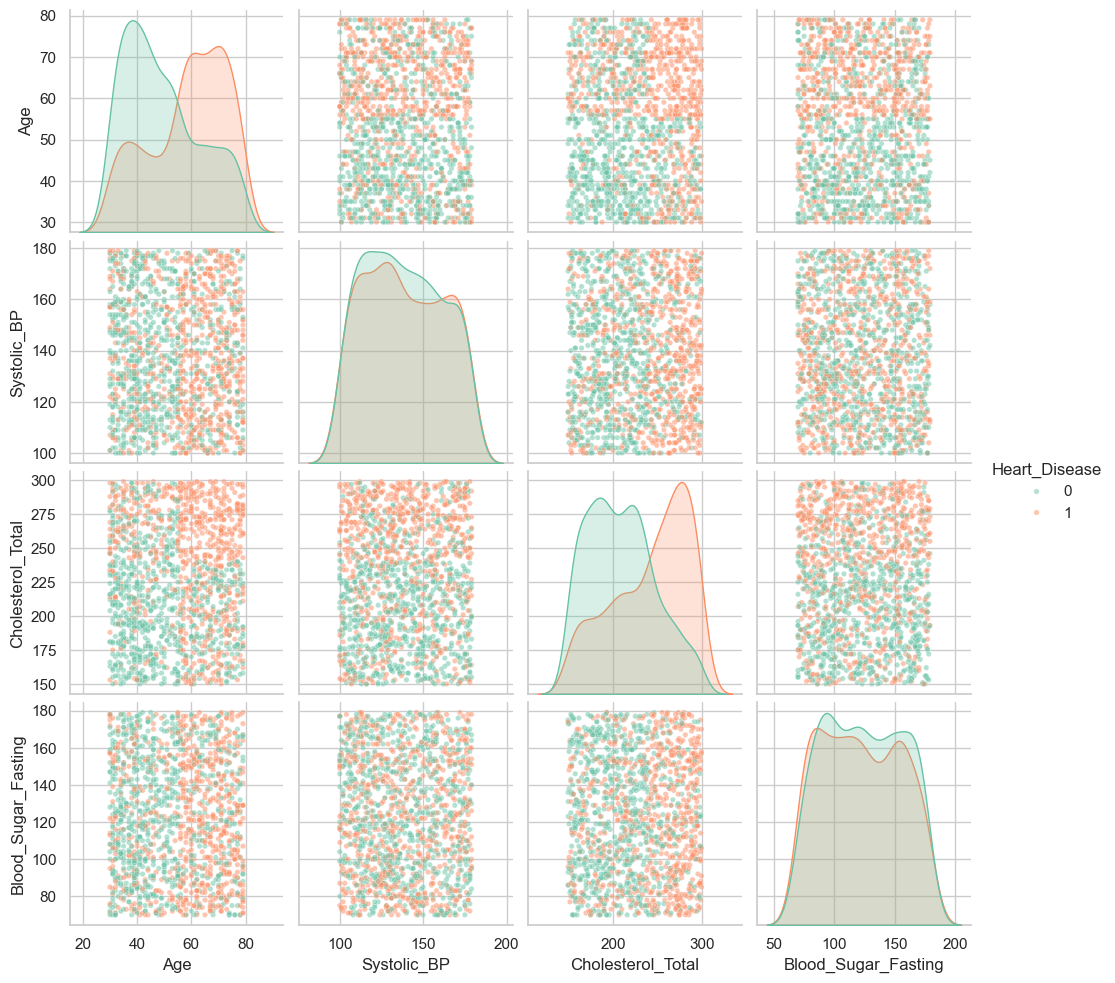

In [23]:
sample = df.sample(1500, random_state=42)
pp = sns.pairplot(sample[["Age", "Systolic_BP", "Cholesterol_Total", "Blood_Sugar_Fasting", target]],
                  hue=target, diag_kind="kde", plot_kws={"alpha": 0.5, "s": 15})
pp.fig.savefig("figures/11_pairplot.png", dpi=110)
plt.show()
plt.close()
figs["pair"] = "figures/11_pairplot.png"

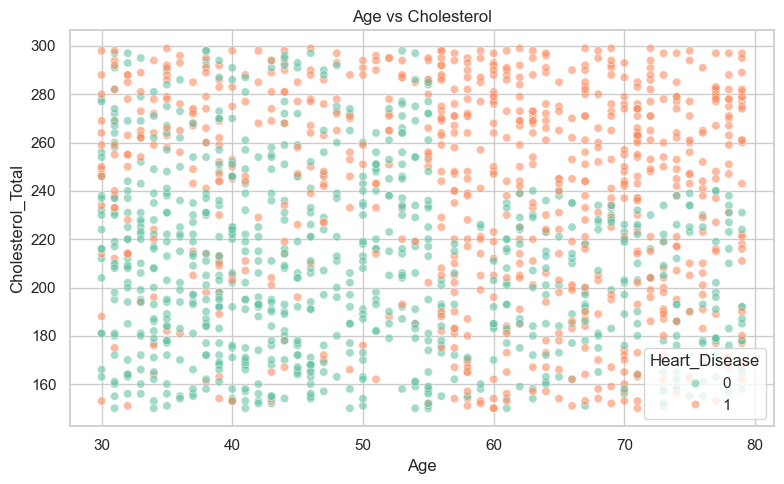

In [24]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="Age", y="Cholesterol_Total", hue=target, data=sample, alpha=0.6)
plt.title("Age vs Cholesterol")
figs["scatter"] = save("12_age_chol")

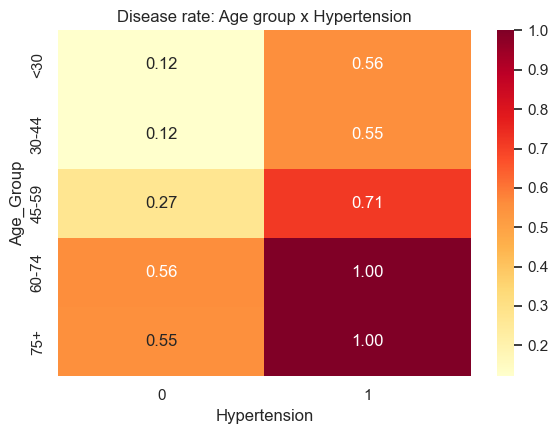

In [25]:
pivot = df.pivot_table(values=target, index="Age_Group", columns="Hypertension", aggfunc="mean")
plt.figure(figsize=(6, 4.5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlOrRd")
plt.title("Disease rate: Age group x Hypertension")
figs["pivot"] = save("13_age_hypertension")


In [26]:
t_res, chi_res = [], []
for c in num_cols:
    a = df.loc[df[target] == 1, c]
    b = df.loc[df[target] == 0, c]
    t, p = stats.ttest_ind(a, b, equal_var=False)
    t_res.append((c, round(t, 2), p))
for c in cat_cols + bin_cols:
    chi2, p, _, _ = stats.chi2_contingency(pd.crosstab(df[c], df[target]))
    chi_res.append((c, round(chi2, 2), p))

print("\n--- T-TESTS ---")
for c, t, p in t_res:
    print(f"{c:22s} t={t:8.2f} p={p:.4g} {'SIG' if p < 0.05 else 'ns'}")
print("\n--- CHI-SQUARE ---")
for c, x, p in chi_res:
    print(f"{c:22s} chi2={x:9.2f} p={p:.4g} {'SIG' if p < 0.05 else 'ns'}")

t_sig = [c for c, _, p in t_res if p < 0.05]
chi_sig = [c for c, _, p in chi_res if p < 0.05]


--- T-TESTS ---
Age                    t=   91.90 p=0 SIG
Weight                 t=   -1.20 p=0.2293 ns
Height                 t=   -0.24 p=0.81 ns
BMI                    t=   -1.47 p=0.1413 ns
Systolic_BP            t=   -0.15 p=0.8786 ns
Diastolic_BP           t=    0.70 p=0.4841 ns
Heart_Rate             t=   -1.59 p=0.1107 ns
Blood_Sugar_Fasting    t=   -0.77 p=0.4404 ns
Cholesterol_Total      t=   89.65 p=0 SIG

--- CHI-SQUARE ---
Gender                 chi2=     0.71 p=0.3994 ns
Smoking                chi2=     0.15 p=0.9264 ns
Alcohol_Intake         chi2=     0.34 p=0.9519 ns
Physical_Activity      chi2=     0.53 p=0.7689 ns
Diet                   chi2=     0.76 p=0.6842 ns
Stress_Level           chi2=     1.46 p=0.4822 ns
Hypertension           chi2=  8185.77 p=0 SIG
Diabetes               chi2=  5718.22 p=0 SIG
Hyperlipidemia         chi2=     0.71 p=0.3993 ns
Family_History         chi2=     0.01 p=0.9167 ns
Previous_Heart_Attack  chi2=  2962.53 p=0 SIG



RF preview -> Accuracy: 1.000 | ROC-AUC: 1.000
Cholesterol_Total        0.244
Age                      0.244
Hypertension             0.208
Diabetes                 0.145
Previous_Heart_Attack    0.077
BMI                      0.010
Blood_Sugar_Fasting      0.010
Systolic_BP              0.009
Weight                   0.009
Diastolic_BP             0.009
dtype: float64


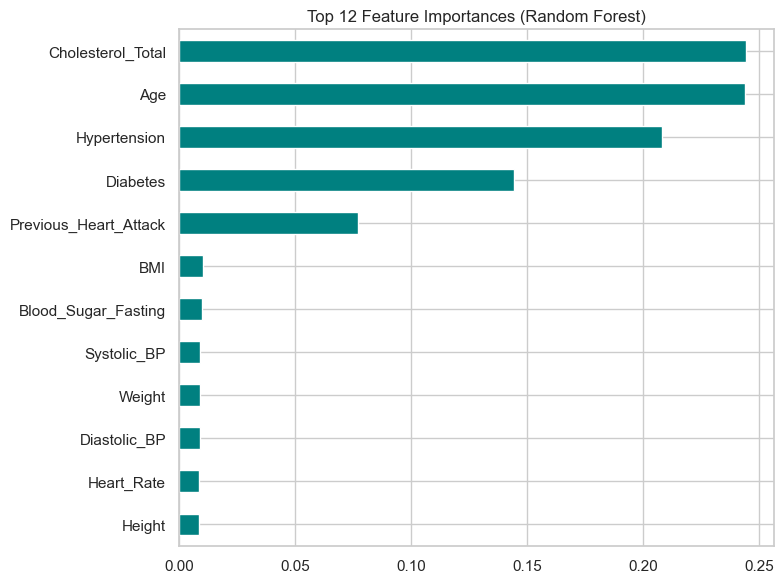

In [27]:
X = pd.get_dummies(df[num_cols + bin_cols + cat_cols], columns=cat_cols, drop_first=True)
y = df[target]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1).fit(Xtr, ytr)
acc = accuracy_score(yte, rf.predict(Xte))
auc = roc_auc_score(yte, rf.predict_proba(Xte)[:, 1])
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(f"\nRF preview -> Accuracy: {acc:.3f} | ROC-AUC: {auc:.3f}")
print(imp.head(10).round(3))

plt.figure(figsize=(8, 6))
imp.head(12).sort_values().plot(kind="barh", color="teal")
plt.title("Top 12 Feature Importances (Random Forest)")
figs["imp"] = save("14_importance")


In [31]:
def rate(col):
    return (df.groupby(col, observed=True)[target].mean() * 100).round(1)

rates = {c: rate(c) for c in ["Age_Group", "Gender", "Smoking", "Physical_Activity",
                              "Diet", "Stress_Level", "Hypertension", "Diabetes",
                              "Previous_Heart_Attack", "Chol_Category", "BMI_Category"]}
means_by_target = df.groupby(target)[num_cols].mean().round(2).reset_index()


In [33]:
doc = Document()
doc.styles["Normal"].font.name = "Calibri"
doc.styles["Normal"].font.size = Pt(11)

def table(frame):
    t = doc.add_table(rows=1, cols=len(frame.columns))
    t.style = "Light Grid Accent 1"
    for i, c in enumerate(frame.columns):
        t.rows[0].cells[i].text = str(c)
    for _, r in frame.iterrows():
        cells = t.add_row().cells
        for i, v in enumerate(r):
            cells[i].text = str(v)

def fig(path, caption, w=6.2):
    doc.add_picture(path, width=Inches(w))
    doc.paragraphs[-1].alignment = WD_ALIGN_PARAGRAPH.CENTER
    p = doc.add_paragraph(caption)
    p.alignment = WD_ALIGN_PARAGRAPH.CENTER
    p.runs[0].italic = True

def bullets(items):
    for i in items:
        doc.add_paragraph(i, style="List Bullet")

def fmt(s):
    return ", ".join(f"{k}: {v}%" for k, v in s.items())

h = doc.add_heading("Exploratory Data Analysis: Heart Disease Dataset", 0)
h.alignment = WD_ALIGN_PARAGRAPH.CENTER
doc.add_paragraph("Objective: analyse the dataset to uncover patterns and trends, identify "
                  "correlations and the key factors influencing heart disease.")


In [34]:
doc.add_heading("1. Dataset Overview", 1)
bullets([
    f"Records: {len(df):,}; Columns: {df.shape[1] - 6} original (21 incl. target).",
    f"Missing values: {n_missing}; duplicate rows: {n_dupes}. "
    "'None' in Alcohol_Intake means no alcohol, so it was treated as a category.",
    "Class balance: " + ", ".join(f"class {k} = {v}%" for k, v in class_pct.items()) + ".",
    f"Numerical features: {', '.join(num_cols)}.",
    f"Binary risk factors: {', '.join(bin_cols)}.",
    f"Categorical features: {', '.join(cat_cols)}.",
])
fig(figs["target"], "Figure 1: Target distribution", 3.3)

In [35]:
doc.add_heading("2. Statistical Summaries", 1)
s = summary.reset_index().rename(columns={"index": "feature", "50%": "median"})
table(s[["feature", "mean", "std", "min", "median", "max"]])
doc.add_paragraph()
doc.add_paragraph("Skewness: " + ", ".join(f"{k} = {v:.2f}" for k, v in sk["skew"].items()) + ".")
doc.add_paragraph("Outliers (IQR rule): " + ", ".join(f"{k} = {v}" for k, v in outliers.items()) + ".")
fig(figs["hist"], "Figure 2: Distributions of numerical features")

In [36]:
doc.add_heading("3. Visual Exploration", 1)
doc.add_heading("3.1 Numerical features vs target", 2)
table(means_by_target)
fig(figs["box"], "Figure 3: Boxplots by heart disease status")
fig(figs["kde"], "Figure 4: Density plots by heart disease status")
doc.add_heading("3.2 Categorical features vs target", 2)
fig(figs["cat_rate"], "Figure 5: Disease rate by lifestyle categories")
doc.add_heading("3.3 Medical risk factors", 2)
fig(figs["bin_rate"], "Figure 6: Disease rate by medical history", 6.5)
fig(figs["groups"], "Figure 7: Disease rate by age, BMI, BP and cholesterol group", 6.5)

In [39]:
doc.add_heading("4. Correlations and Key Influencing Factors", 1)
fig(figs["heat"], "Figure 8: Correlation heatmap")
fig(figs["tcorr"], "Figure 9: Correlation with Heart_Disease", 5)
doc.add_paragraph("Strongest positive correlations: " +
                  ", ".join(f"{k} ({v:.2f})" for k, v in target_corr.head(4).items()) + ".")
doc.add_paragraph("Features with near-zero correlation: " +
                  ", ".join(target_corr[target_corr.abs() < 0.02].index) + ".")
doc.add_heading("Statistical significance (p < 0.05)", 2)
doc.add_paragraph("Numerical (Welch t-test): " + (", ".join(t_sig) or "none") + ".")
doc.add_paragraph("Categorical/binary (chi-square): " + (", ".join(chi_sig) or "none") + ".")
fig(figs["imp"], "Figure 10: Random Forest feature importance", 5)
doc.add_paragraph(f"A quick Random Forest gave accuracy {acc:.2%} and ROC-AUC {auc:.3f}. "
                  "Top features: " + ", ".join(imp.head(5).index) + ".")

In [40]:
doc.add_heading("5. Key Insights", 1)
bullets([
    "Disease rate by age group: " + fmt(rates["Age_Group"]) + ".",
    "By hypertension (0/1): " + fmt(rates["Hypertension"]) + ".",
    "By diabetes (0/1): " + fmt(rates["Diabetes"]) + ".",
    "By previous heart attack (0/1): " + fmt(rates["Previous_Heart_Attack"]) + ".",
    "By cholesterol category: " + fmt(rates["Chol_Category"]) + ".",
    "By smoking status: " + fmt(rates["Smoking"]) + ".",
    "By physical activity: " + fmt(rates["Physical_Activity"]) + ".",
    "By gender: " + fmt(rates["Gender"]) + ".",
    "Features that are both highly correlated and important in the model are the "
    "most reliable drivers of heart disease in this dataset.",
])
doc.add_paragraph("Note: this is a synthetic dataset, so findings describe patterns in this "
                  "data and should not be treated as real medical evidence.").runs[0].italic = True

In [41]:
doc.add_heading("6. Conclusion and Next Steps", 1)
bullets([
    "EDA identified which clinical and lifestyle factors separate patients with and without heart disease.",
    "Next: encode categorical variables, scale numeric ones, and build models "
    "(Logistic Regression, Random Forest, XGBoost).",
    "Evaluate with accuracy, precision, recall, F1 and ROC-AUC.",
])

doc.save("Heart_Disease_EDA_Report.docx")
print("\nDone! Report saved: Heart_Disease_EDA_Report.docx | Charts in ./figures")


Done! Report saved: Heart_Disease_EDA_Report.docx | Charts in ./figures


In [3]:
import os
for root, dirs, files in os.walk(r"C:\Users\acer"):
    if "Heart_Disease_EDA_Report.docx" in files:
        print("FILE FOUND:", os.path.join(root, "Heart_Disease_EDA_Report.docx"))
        os.startfile(os.path.join(root, "Heart_Disease_EDA_Report.docx"))
        break
else:
    print("File not saved yet, please re-run the code above")

FILE FOUND: C:\Users\acer\Heart_Disease_EDA_Report.docx
